In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

print("TensorFlow :", tf.__version__)
print("GPU :", tf.config.list_physical_devices("GPU"))

2026-06-26 07:58:32.918907: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782460713.183236      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782460713.259399      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782460713.863098      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782460713.863145      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782460713.863148      24 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/notebooks
/kaggle/input/notebooks/hapizh
/kaggle/input/notebooks/hapizh/deeplearning1
/kaggle/input/notebooks/hapizh/deeplearning1/experiments
/kaggle/input/notebooks/hapizh/deeplearning1/experiments/E1_ResNet50_LR001
/kaggle/input/notebooks/hapizh/deeplearning1/experiments/E3_ResNet50_LR0001
/kaggle/input/notebooks/hapizh/deeplearning1/experiments/E5_DenseNet121_LR0005
/kaggle/input/notebooks/hapizh/deeplearning1/experiments/E4_DenseNet121_LR001
/kaggle/input/notebooks/hapizh/deeplearning1/experiments/E2_ResNet50_LR0005
/kaggle/input/notebooks/hapizh/deeplearning1/__results___files
/kaggle/input/notebooks/hapizh/deeplearning1/classification_dataset
/kaggle/input/notebooks/hapizh/deeplearning1/classification_dataset/valid
/kaggle/input/notebooks/hapizh/deeplearning1/classification_dataset/valid/normal
/kaggle/input/notebooks/hapizh/deeplearning1/classification_dataset/valid/scoliosis
/kaggle/input/notebooks/hapizh/deeplearning1/classification_dataset/test
/k

In [3]:
BASE_PATH = "/kaggle/input/notebooks/hapizh/deeplearning1"

DATASET_PATH = os.path.join(
    BASE_PATH,
    "classification_dataset"
)

MODEL_PATH = os.path.join(
    BASE_PATH,
    "experiments",
    "E4_DenseNet121_LR001",
    "best_densenet121_e4.keras"
)

print(DATASET_PATH)
print(MODEL_PATH)

/kaggle/input/notebooks/hapizh/deeplearning1/classification_dataset
/kaggle/input/notebooks/hapizh/deeplearning1/experiments/E4_DenseNet121_LR001/best_densenet121_e4.keras


In [4]:
print("="*50)

print("DATASET")

print(os.path.exists(DATASET_PATH))

print()

print("MODEL")

print(os.path.exists(MODEL_PATH))

print("="*50)

DATASET
True

MODEL
True


In [5]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

print("Configuration Loaded")

Configuration Loaded


In [6]:
#Test gen
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(

    os.path.join(
        DATASET_PATH,
        "test"
    ),

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="binary",

    shuffle=False
)

Found 98 images belonging to 2 classes.


In [7]:
print("="*50)
print("TEST GENERATOR")
print("="*50)

print()

print("Images :", test_generator.samples)

print("Classes :", test_generator.class_indices)

TEST GENERATOR

Images : 98
Classes : {'normal': 0, 'scoliosis': 1}


In [8]:
best_model = load_model(MODEL_PATH)

print("="*50)
print("MODEL BERHASIL DIMUAT")
print("="*50)

best_model.summary()

I0000 00:00:1782460732.213624      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782460732.219678      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


MODEL BERHASIL DIMUAT


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,040,581 (26.86 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 2,052 (8.02 KB)

In [9]:
test_loss, test_accuracy = best_model.evaluate(
    test_generator,
    verbose=1
)

print("\n" + "="*50)
print("HASIL EVALUASI TEST SET")
print("="*50)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

I0000 00:00:1782460744.582159      76 service.cc:152] XLA service 0x7a5d34003370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782460744.582214      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782460744.582221      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782460746.434428      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/4 ━━━━━━━━━━━━━━━━━━━━ 59s 20s/step - accuracy: 0.9375 - loss: 0.2246

I0000 00:00:1782460757.717982      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.8571 - loss: 0.3305

HASIL EVALUASI TEST SET
Test Accuracy : 0.8571
Test Loss     : 0.3305


In [10]:
probabilities = best_model.predict(
    test_generator,
    verbose=1
)

predictions = (probabilities > 0.5).astype(int).flatten()

true_labels = test_generator.classes

class_names = list(
    test_generator.class_indices.keys()
)

print("="*50)
print("PREDIKSI SELESAI")
print("="*50)

print("Jumlah Test :", len(true_labels))

4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step
PREDIKSI SELESAI
Jumlah Test : 98


In [11]:
accuracy = accuracy_score(
    true_labels,
    predictions
)

precision = precision_score(
    true_labels,
    predictions
)

recall = recall_score(
    true_labels,
    predictions
)

f1 = f1_score(
    true_labels,
    predictions
)

print("="*50)
print("METRIK EVALUASI")
print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

METRIK EVALUASI
Accuracy  : 0.8571
Precision : 0.9636
Recall    : 0.8154
F1-Score  : 0.8833


In [12]:
print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)

print(
    classification_report(
        true_labels,
        predictions,
        target_names=class_names
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      normal       0.72      0.94      0.82        33
   scoliosis       0.96      0.82      0.88        65

    accuracy                           0.86        98
   macro avg       0.84      0.88      0.85        98
weighted avg       0.88      0.86      0.86        98



In [13]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_labels,
    predictions
)

print(cm)

[[31  2]
 [12 53]]


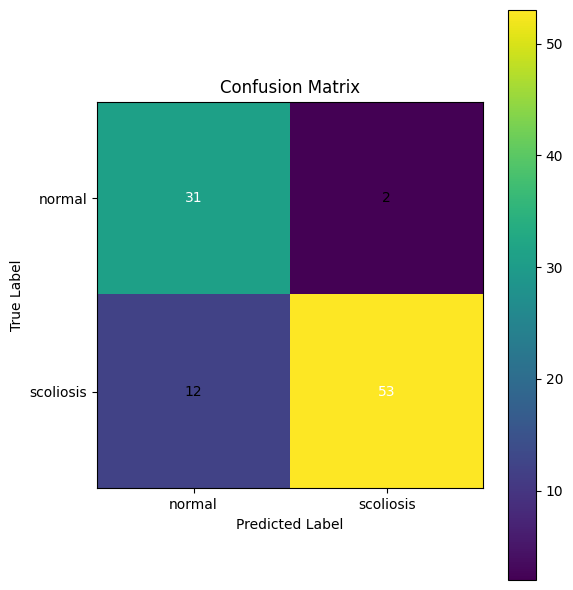

In [14]:
plt.figure(figsize=(6,6))

plt.imshow(cm, interpolation='nearest')

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(
    tick_marks,
    class_names
)

plt.yticks(
    tick_marks,
    class_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black"
        )

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.tight_layout()

plt.show()

In [15]:
tn, fp, fn, tp = cm.ravel()

print("="*50)
print("CONFUSION MATRIX")
print("="*50)

print(f"True Negative : {tn}")

print(f"False Positive: {fp}")

print(f"False Negative: {fn}")

print(f"True Positive : {tp}")

CONFUSION MATRIX
True Negative : 31
False Positive: 2
False Negative: 12
True Positive : 53


In [16]:
image_paths = test_generator.filepaths

results = pd.DataFrame({
    "filepath": image_paths,
    "true_label": true_labels,
    "pred_label": predictions
})

results["correct"] = (
    results["true_label"] == results["pred_label"]
)

results.head()

,filepath,true_label,pred_label,correct
0,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,1,False
1,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,0,True
2,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,0,True
3,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,0,True
4,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,0,True


In [17]:
correct_predictions = results[
    results["correct"] == True
].reset_index(drop=True)

wrong_predictions = results[
    results["correct"] == False
].reset_index(drop=True)

print("="*50)
print("JUMLAH PREDIKSI")
print("="*50)

print("Correct :", len(correct_predictions))
print("Wrong   :", len(wrong_predictions))

JUMLAH PREDIKSI
Correct : 84
Wrong   : 14


In [18]:
from tensorflow.keras.preprocessing import image

def show_predictions(df, title):

    plt.figure(figsize=(15,8))

    for i in range(5):

        plt.subplot(1,5,i+1)

        img = image.load_img(
            df.loc[i,"filepath"],
            target_size=(224,224)
        )

        plt.imshow(img)

        true_name = class_names[
            df.loc[i,"true_label"]
        ]

        pred_name = class_names[
            df.loc[i,"pred_label"]
        ]

        plt.title(
            f"True : {true_name}\nPred : {pred_name}",
            fontsize=9
        )

        plt.axis("off")

    plt.suptitle(title, fontsize=15)

    plt.tight_layout()

    plt.show()

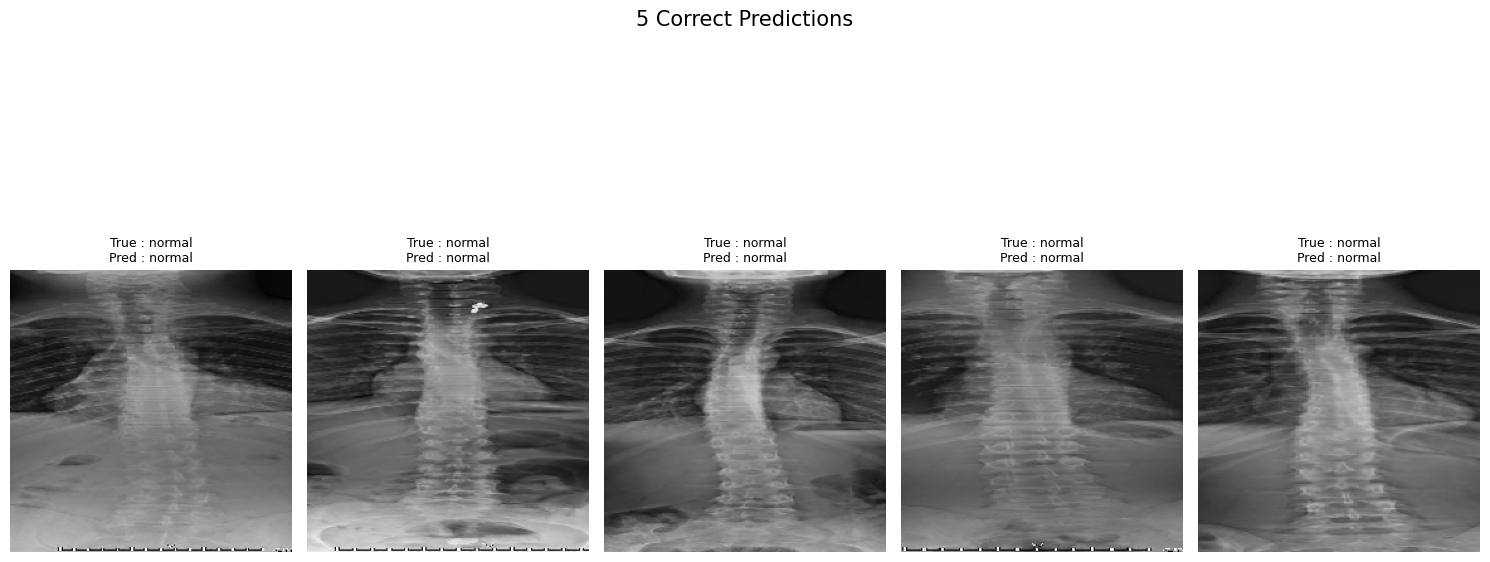

In [19]:
show_predictions(
    correct_predictions,
    "5 Correct Predictions"
)

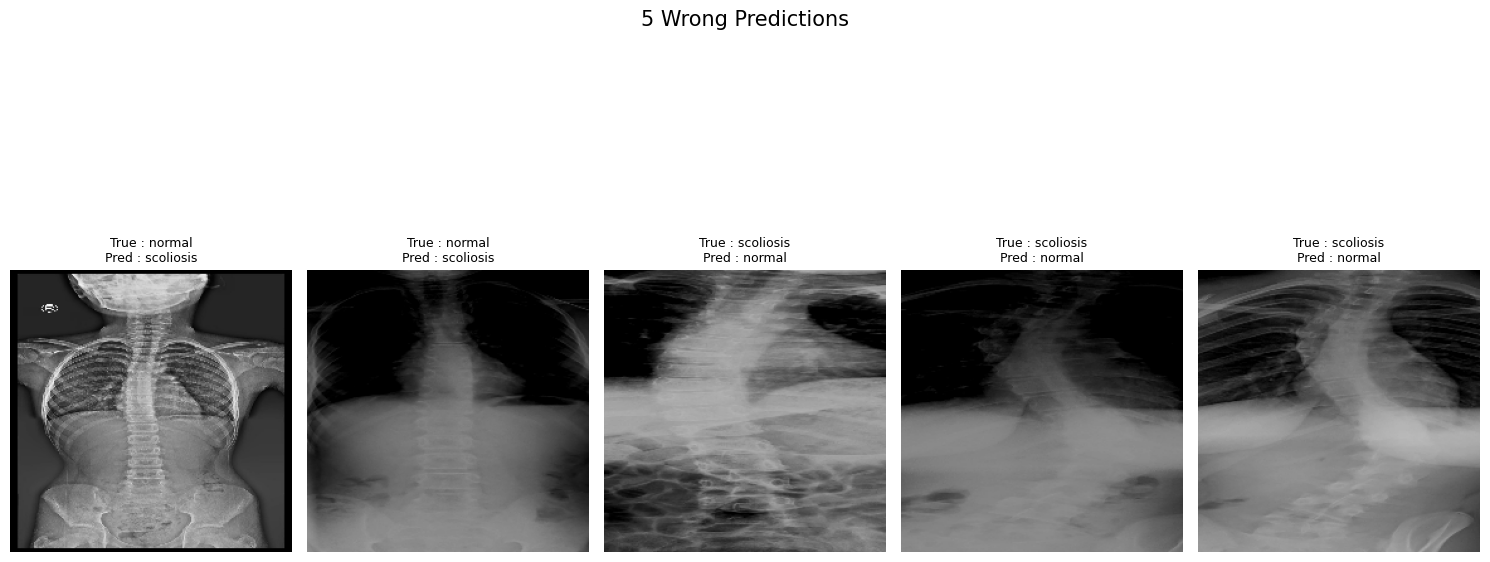

In [20]:
show_predictions(
    wrong_predictions,
    "5 Wrong Predictions"
)

In [21]:
pred_probs = best_model.predict(test_generator, verbose=0)

print(pred_probs.shape)

print(pred_probs[:5])

(98, 1)
[[0.88779914]
 [0.09840707]
 [0.0644166 ]
 [0.3069046 ]
 [0.17288184]]


In [22]:
# ==========================================================
# EXPORT PREDICTION RESULTS 
# ==========================================================

import pandas as pd
import numpy as np
import os

# ==========================================================
# MODEL PREDICTION
# ==========================================================

pred_probs = best_model.predict(
    test_generator,
    verbose=0
)

# ==========================================================
# SUPPORT BOTH SIGMOID & SOFTMAX
# ==========================================================

if pred_probs.shape[1] == 1:

    # Binary Sigmoid
    confidence_scoliosis = pred_probs.flatten()

    confidence_normal = 1 - confidence_scoliosis

    pred_labels = (
        confidence_scoliosis >= 0.5
    ).astype(int)

else:

    # Softmax
    confidence_normal = pred_probs[:, 0]

    confidence_scoliosis = pred_probs[:, 1]

    pred_labels = np.argmax(pred_probs, axis=1)

# ==========================================================
# TRUE LABEL
# ==========================================================

true_labels = test_generator.classes

idx_to_class = {
    v: k
    for k, v in test_generator.class_indices.items()
}

# ==========================================================
# CREATE DATAFRAME
# ==========================================================

results = pd.DataFrame({

    "filepath": test_generator.filepaths,

    "true_label": true_labels,

    "true_class": [
        idx_to_class[i]
        for i in true_labels
    ],

    "pred_label": pred_labels,

    "pred_class": [
        idx_to_class[i]
        for i in pred_labels
    ],

    "confidence_normal": confidence_normal,

    "confidence_scoliosis": confidence_scoliosis

})

# ==========================================================
# ADD PREDICTED PROBABILITY
# ==========================================================

results["predicted_probability"] = results.apply(

    lambda row:

    row.confidence_normal

    if row.pred_label == 0

    else row.confidence_scoliosis,

    axis=1
)

# ==========================================================
# ADD CONFIDENCE LEVEL
# ==========================================================

def confidence_level(prob):

    if prob >= 0.95:
        return "Very High"

    elif prob >= 0.85:
        return "High"

    elif prob >= 0.70:
        return "Moderate"

    else:
        return "Low"


results["confidence_level"] = (
    results["predicted_probability"]
    .apply(confidence_level)
)

# ==========================================================
# ADD CORRECT FLAG
# ==========================================================

results["correct"] = (

    results["true_label"]

    ==

    results["pred_label"]

)

# ==========================================================
# ADD PREDICTION TYPE
# ==========================================================

def prediction_type(row):

    if row.true_label == 0 and row.pred_label == 0:
        return "True Negative"

    elif row.true_label == 0 and row.pred_label == 1:
        return "False Positive"

    elif row.true_label == 1 and row.pred_label == 0:
        return "False Negative"

    else:
        return "True Positive"


results["prediction_type"] = results.apply(

    prediction_type,

    axis=1

)

# ==========================================================
# ADD PREDICTION ID
# ==========================================================

results.insert(

    0,

    "prediction_id",

    range(1, len(results)+1)

)

# ==========================================================
# DISPLAY
# ==========================================================

display(results.head())

print()

print("Total Images :", len(results))

,prediction_id,filepath,true_label,true_class,pred_label,pred_class,confidence_normal,confidence_scoliosis,predicted_probability,confidence_level,correct,prediction_type
0,1,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,normal,1,scoliosis,0.112201,0.887799,0.887799,High,False,False Positive
1,2,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,normal,0,normal,0.901593,0.098407,0.901593,High,True,True Negative
2,3,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,normal,0,normal,0.935583,0.064417,0.935583,High,True,True Negative
3,4,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,normal,0,normal,0.693095,0.306905,0.693095,Low,True,True Negative
4,5,/kaggle/input/notebooks/hapizh/deeplearning1/c...,0,normal,0,normal,0.827118,0.172882,0.827118,Moderate,True,True Negative



Total Images : 98


In [23]:
#Save CSV
OUTPUT_DIR = "/kaggle/working/evaluation"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

csv_path = os.path.join(
    OUTPUT_DIR,
    "prediction_results.csv"
)

results.to_csv(
    csv_path,
    index=False
)

print("="*60)
print("Prediction Results Saved")
print("="*60)
print(csv_path)

Prediction Results Saved
/kaggle/working/evaluation/prediction_results.csv


In [24]:
evaluation_summary = {

    "project": "Spine X-Ray Classification",

    "model_name": "DenseNet121",

    "experiment": "E4",

    "dataset_name": "classification_dataset",

    "positive_class": "scoliosis",

    "negative_class": "normal",

    "output_activation": "sigmoid",

    "decision_threshold": 0.5,

    "training_preprocessing": "rescale_1_over_255",

    "image_size": [224,224],

    "batch_size": int(test_generator.batch_size),

    "num_test_images": int(len(results)),

    "num_correct": int(results["correct"].sum()),

    "num_wrong": int((~results["correct"]).sum()),

    "test_accuracy": float(test_accuracy),

    "test_loss": float(test_loss),

    "precision": float(precision),

    "recall": float(recall),

    "f1_score": float(f1),

    "class_indices": test_generator.class_indices

}

In [25]:
results["prediction_status"] = np.where(
    results["correct"],
    "Correct",
    "Incorrect"
)

# Save Output

In [26]:
# ==========================================================
# SAVE EVALUATION SUMMARY
# ==========================================================

import json
import os

OUTPUT_DIR = "/kaggle/working/evaluation"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

json_path = os.path.join(
    OUTPUT_DIR,
    "evaluation_summary.json"
)

with open(json_path, "w") as f:

    json.dump(

        evaluation_summary,

        f,

        indent=4

    )

print("="*60)
print("Evaluation Summary Saved")
print("="*60)
print(json_path)

Evaluation Summary Saved
/kaggle/working/evaluation/evaluation_summary.json


In [27]:
# ==========================================================
# VERIFY OUTPUT
# ==========================================================

print("="*60)
print("Evaluation Folder")
print("="*60)

for file in os.listdir(OUTPUT_DIR):
    print(file)

Evaluation Folder
evaluation_summary.json
prediction_results.csv


In [28]:
# ==========================================================
# NOTEBOOK VARIABLES
# ==========================================================

print("="*70)
print("GLOBAL VARIABLES")
print("="*70)

for name in sorted(globals()):

    if not name.startswith("_"):

        print(name)

GLOBAL VARIABLES
BASE_PATH
BATCH_SIZE
DATASET_PATH
IMAGE_SIZE
ImageDataGenerator
In
MODEL_PATH
OUTPUT_DIR
Out
accuracy
accuracy_score
best_model
class_names
classification_report
cm
confidence_level
confidence_normal
confidence_scoliosis
confusion_matrix
correct_predictions
csv_path
dirs
evaluation_summary
exit
f
f1
f1_score
file
files
fn
fp
get_ipython
i
idx_to_class
image
image_paths
j
json
json_path
load_model
np
os
pd
plt
precision
precision_score
pred_labels
pred_probs
prediction_type
predictions
probabilities
quit
random
recall
recall_score
results
root
show_predictions
test_accuracy
test_datagen
test_generator
test_loss
tf
tick_marks
tn
tp
true_labels
warnings
wrong_predictions
